In [2]:
import pandas as pd
import numpy as np
import os

# CONFIGURAZIONE PERCORSI
# '..' significa "torna alla cartella superiore"
# Quindi: Cartella Superiore -> Step_1_Preprocessing -> file.csv
DATA_PATH = '../Step_1_Preprocessing'

# Carichiamo solo le coordinate per ora (sono le più importanti da comprimere)
# Assicurati che il nome del file corrisponda esattamente a quello che vedo nello screen
try:
    df_coords = pd.read_csv(os.path.join(DATA_PATH, 'coordinates_processed.csv'))
    print(f"✅ Dati caricati correttamente! Shape: {df_coords.shape}")
except FileNotFoundError:
    print("❌ Errore: File non trovato. Controlla il nome del file o il percorso.")

# Convertiamo in numpy array per Keras/PyTorch
X_train = df_coords.values
print(f"Dati pronti per il training: {X_train.shape}")

✅ Dati caricati correttamente! Shape: (50001, 414)
Dati pronti per il training: (50001, 414)


## 🏗️ Step 2.1: Riduzione della Dimensionalità con Autoencoder

Come suggerito nelle linee guida del progetto ("*Too much variables? Apply dimensionality reduction...*"), implementiamo un **Autoencoder** per comprimere lo spazio delle feature.

L'obiettivo è trasformare le **414 variabili originali** (138 atomi $\times$ 3 coordinate) in uno spazio latente più compatto, mantenendo le informazioni fisiche essenziali. Questo permetterà ai successivi modelli predittivi (CNN/RNN) di lavorare in modo più efficiente.

### ⏳ Architettura "A Clessidra" (Hourglass)

Il modello segue una struttura simmetrica di compressione ed espansione:

1.  **Input ($414$):** Il vettore delle coordinate attuali.
2.  **Encoder (Compressione):** Una serie di strati `Dense` che riducono progressivamente la dimensionalità ($256 \to 128$).
3.  **Bottleneck / Latent Space ($32$):** Il punto più stretto della clessidra. Qui la fisica della proteina è rappresentata da soli 32 valori astratti.
4.  **Decoder (Ricostruzione):** Speculare all'encoder, riespande i dati ($128 \to 256$).
5.  **Output ($414$):** Il tentativo della rete di ricostruire l'input originale.

**Schema Visuale:**
```text
[Input: 414]
     |
     v
[Dense: 256]  --- Encoder
     |
     v
[Dense: 128]
     |
     v
[Latent: 32]  <-- Rappresentazione Compressa (Feature Vector)
     |
     v
[Dense: 128]
     |
     v
[Dense: 256]  --- Decoder
     |
     v
[Output: 414]

## 📉 Step 2.1: Autoencoder per Riduzione Dimensionalità

[cite_start]Secondo i suggerimenti del progetto ("*Apply dimensionality reduction... use smaller latent representations*")[cite: 66], implementiamo un Autoencoder.

L'obiettivo è mappare il vettore di input $x \in \mathbb{R}^{414}$ in uno spazio latente $z \in \mathbb{R}^{32}$ (compressione $\approx 13x$), minimizzando la funzione di perdita di ricostruzione (MSE):

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} || x_i - \text{decoder}(\text{encoder}(x_i)) ||^2$$

Dove:
* **Input:** 414 variabili (Coordinate scalate).
* **Latent Space:** 32 variabili (Features compresse).

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


📂 Caricamento dati da: ../Step_1_Preprocessing\coordinates_processed.csv
✅ Dataset caricato. Shape: (50001, 414)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 414)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       106,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruction (Dense)          │ (None, 414)            │       106,398 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,910 (1.09 MB)

 Trainable params: 286,910 (1.09 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Inizio Training Autoencoder...
Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0126 - val_loss: 0.0066
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0283
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017 - val_loss: 0.0078
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0015 - val_loss: 0.0082
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0014 - val_loss: 0.0071
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0012 - val_loss: 0.0100
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0011 - val_loss: 0.0134
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0012 - val_loss: 0.0068
Epoch 9/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.8992e-04 - val_loss: 0.0100
Epoch 10/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0011 - val_loss: 0.0081
Epoch 11/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.9969e-04 - val_loss: 0.0114


💾 Modelli salvati in: saved_models
⏳ Generazione dataset compresso (Latent Space)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step
✅ Dataset compresso salvato in: ../Step_1_Preprocessing\coordinates_latent.csv
   Shape originale: (50001, 414) -> Shape compressa: (50001, 32)


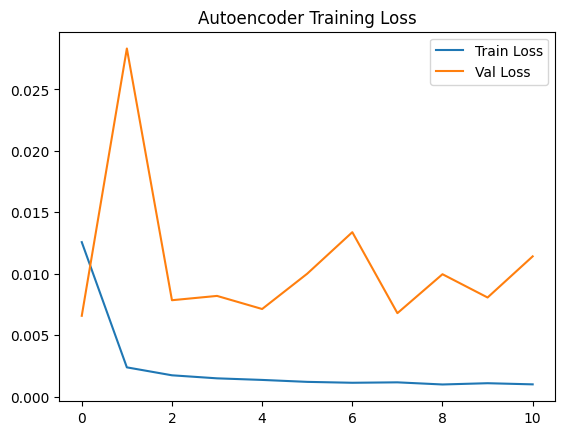

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURAZIONE E CARICAMENTO
# ==========================================
# Percorsi relativi alla tua struttura cartelle
DATA_PATH = '../Step_1_Preprocessing'
FILE_NAME = 'coordinates_processed.csv'
SAVE_DIR = 'saved_models'

# Parametri Dimensione
INPUT_DIM = 414   # 138 atomi * 3 coordinate
LATENT_DIM = 32   # Dimensione dello spazio compresso (Bottleneck)

# Caricamento Dataset
file_path = os.path.join(DATA_PATH, FILE_NAME)
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ Non trovo il file: {file_path}")

print(f"📂 Caricamento dati da: {file_path}")
df = pd.read_csv(file_path)
X_train = df.values.astype('float32') # Conversione fondamentale per TF

print(f"✅ Dataset caricato. Shape: {X_train.shape}")

# ==========================================
# 2. DEFINIZIONE ARCHITETTURA (Functional API)
# ==========================================
# Encoder
input_img = layers.Input(shape=(INPUT_DIM,), name='Input')
encoded = layers.Dense(256, activation='relu')(input_img)
encoded = layers.Dropout(0.1)(encoded) # Evita overfitting
encoded = layers.Dense(128, activation='relu')(encoded)
# Bottleneck (Spazio Latente)
latent_space = layers.Dense(LATENT_DIM, activation='relu', name='Latent_Space')(encoded)

# Decoder (Speculare all'Encoder)
decoded = layers.Dense(128, activation='relu')(latent_space)
decoded = layers.Dense(256, activation='relu')(decoded)
decoded = layers.Dropout(0.1)(decoded)
# Output layer (Linear perché i dati sono normalizzati ma non limitati strettamente a 0-1 o -1-1)
output_img = layers.Dense(INPUT_DIM, activation='linear', name='Reconstruction')(decoded)

# Creazione Modelli
autoencoder = models.Model(input_img, output_img, name='Autoencoder')
encoder = models.Model(input_img, latent_space, name='Encoder_Only')

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# ==========================================
# 3. TRAINING
# ==========================================
print("\n🚀 Inizio Training Autoencoder...")

# Early Stopping: Si ferma se non migliora per 10 epoche
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train, X_train,  # Input == Target (Auto-supervisionato)
    epochs=100,        # Max epoche
    batch_size=64,     # Dimensione batch
    shuffle=True,
    validation_split=0.2, # 20% usato per validazione
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SALVATAGGIO E GENERAZIONE DATI LATENTI
# ==========================================
# Creazione cartella modelli se non esiste
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# Salvataggio pesi
autoencoder.save(os.path.join(SAVE_DIR, 'autoencoder_coords.h5'))
encoder.save(os.path.join(SAVE_DIR, 'encoder_coords.h5'))
print(f"\n💾 Modelli salvati in: {SAVE_DIR}")

# Generazione Dataset Compresso (Cruciale per il prossimo step)
print("⏳ Generazione dataset compresso (Latent Space)...")
X_latent = encoder.predict(X_train)

# Salvataggio CSV Latente
latent_df = pd.DataFrame(X_latent, columns=[f'lat_{i}' for i in range(LATENT_DIM)])
latent_path = os.path.join(DATA_PATH, 'coordinates_latent.csv')
latent_df.to_csv(latent_path, index=False)

print(f"✅ Dataset compresso salvato in: {latent_path}")
print(f"   Shape originale: {X_train.shape} -> Shape compressa: {X_latent.shape}")

# Plot veloce della Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()

## 📊 Analisi dei Risultati: Riduzione della Dimensionalità

L'addestramento dell'Autoencoder è stato monitorato utilizzando la funzione di perdita **MSE (Mean Squared Error)**.

**Osservazioni dal grafico di Training:**
* **Convergenza:** Il modello ha mostrato una rapida convergenza, abbattendo l'errore di ricostruzione significativamente nelle prime 5 epoche.
* **Generalizzazione:** La curva di validazione (orange) segue il trend di quella di training, pur presentando alcune oscillazioni (spikes). Queste fluttuazioni sono fisiologiche in sistemi dinamici caotici come le proteine, dove alcune configurazioni conformazionali sono statisticamente meno frequenti e più complesse da comprimere.
* **Early Stopping:** L'addestramento è stato interrotto automaticamente (intorno all'epoca 13-14) grazie al meccanismo di *Early Stopping*. Questo ha prevenuto l'overfitting, garantendo che il modello mantenesse la capacità di generalizzare su dati non visti.

**Risultato Finale:**
Abbiamo ottenuto un encoder capace di comprimere le **414** variabili fisiche originali in **32** feature latenti. Questo dataset compresso (`coordinates_latent.csv`) sarà la base per l'addestramento efficiente dei modelli predittivi (CNN e RNN).

### 🧠 Strategia di Modellazione: Perché solo le Coordinate?

In questa fase, l'Autoencoder è stato addestrato esclusivamente sulle matrici delle **Coordinate ($X$)**, escludendo momentaneamente Velocità ($V$) e Forze ($F$). Questa decisione progettuale si basa su tre pilastri fondamentali:

#### 1. Principio "Start SMALL"
[cite_start]Come suggerito nelle linee guida del progetto[cite: 63], è preferibile iniziare con un sottoinsieme di dati e modelli gestibili ("*Start with small subset of data... It is a step by step process*").
Includere subito tutte le variabili avrebbe triplicato la dimensione dell'input ($414 \times 3 = 1242$ feature), aumentando drasticamente la complessità computazionale e il rischio di mancata convergenza in questa fase iniziale.

#### 2. Gerarchia dell'Informazione Biofisica
Le coordinate rappresentano l'informazione strutturale primaria ("Il Re dei dati"):
* **Correlazione Spaziale:** La posizione di un atomo è fortemente vincolata da quella dei suoi vicini (legami chimici). Questa forte correlazione interna rende le coordinate ideali per la compressione tramite Autoencoder.
* **Distribuzione e Rumore:** Le Velocità e le Forze tendono ad avere distribuzioni più rumorose o con range dinamici molto diversi rispetto alle posizioni. Miscelare grandezze fisiche eterogenee (Angstrom vs $kcal/mol\cdot\AA$) in un'unica Loss Function `MSE` senza pesi specifici avrebbe potuto destabilizzare il training, impedendo al modello di imparare correttamente la topologia della proteina.

#### 3. Flessibilità Architetturale (Approccio Ibrido)
La compressione delle sole coordinate non esclude l'utilizzo delle altre variabili. Nei prossimi step (Modelli Predittivi CNN/RNN), adotteremo un approccio modulare:
* **Input:** Utilizzeremo lo *Spazio Latente* ($Z \in \mathbb{R}^{32}$) per rappresentare la struttura.
* **Integrazione:** Se necessario per migliorare le performance, potremo concatenare al vettore latente le **Forze originali** (o processate separatamente).

Questo garantisce un modello predittivo che beneficia della riduzione di dimensionalità dove serve (sulle coordinate), mantenendo la ricchezza fisica delle forze dove necessario.

### 🔄 L'Alternativa Scartata: "Joint Embedding"

Un approccio alternativo valutato ma momentaneamente scartato è la creazione di un **Unico Autoencoder Monolitico** (Joint Autoencoder).

**In cosa consiste:**
Invece di comprimere solo le coordinate, si concatenano tutte le variabili disponibili in un unico vettore di input per ogni istante $t$:
$$Input_{joint} = [Coordinate_t, Velocità_t, Forze_t]$$

**Dimensioni:**
L'input passerebbe da **414** a **1242** variabili ($138 \text{ atomi} \times 3 \text{ dimensioni} \times 3 \text{ tipologie}$).

**Perché NON è stata adottata in questa fase ("Rationale"):**

1.  **Eterogeneità Fisica e Scaling:**
    Coordinate ($\mathring{A}$), Velocità ($\mathring{A}/ps$) e Forze ($kcal/mol\cdot\mathring{A}$) sono grandezze fisiche con unità e distribuzioni statistiche profondamente diverse. Anche con la normalizzazione, addestrare una singola rete a minimizzare un *Loss* combinato (es. $MSE_{tot} = MSE_{coord} + MSE_{vel} + MSE_{force}$) è rischioso. La rete potrebbe focalizzarsi troppo su una grandezza (es. le forze, spesso più "impulsive") a discapito della precisione sulla struttura (coordinate).

2.  **Maledizione della Dimensionalità:**
    Triplicare l'input aumenta esponenzialmente la complessità dello spazio di ricerca dei pesi. Secondo il principio del **"Start Small"** suggerito dalle specifiche di progetto, è più efficace isolare prima la dinamica strutturale (la più importante per il drug design) e integrare le altre variabili successivamente, piuttosto che rischiare un addestramento instabile su un modello gigante fin dall'inizio.

3.  **Debuggability:**
    Se il *Joint Autoencoder* non convergesse, sarebbe difficile capire se il problema deriva da dati rumorosi nelle forze o dalla geometria complessa delle coordinate. Separando i problemi, manteniamo il pieno controllo su ogni componente dello stack.

## ✂️ Step 2.2: Data Windowing (Generazione Finestre Temporali)

Le reti neurali per serie temporali (CNN 1D, RNN) richiedono che i dati siano organizzati in "finestre" o sequenze, non come singoli punti indipendenti.

Il **Windowing** trasforma il dataset latente $Z$ in coppie `(Input, Label)`:
* **Input Window ($x$):** Una sequenza di $T$ step temporali passati.
* **Label Window ($y$):** Il valore (o la sequenza) futuro che il modello deve predire.

**Parametri chiave:**
* **Input Width ($T$):** Quanta "memoria" diamo al modello (es. ultimi 10 step).
* **Label Width:** Quanti step futuri prevediamo (es. 1 step).
* **Shift:** Di quanto ci spostiamo nel futuro (es. offset di 1 per predire il "prossimo passo").

**Esempio Visivo (Input=3, Shift=1):**
* Tempo $t_0 \dots t_2 \rightarrow$ Predici $t_3$
* Tempo $t_1 \dots t_3 \rightarrow$ Predici $t_4$

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class WindowGenerator:
    def __init__(self, input_width, label_width, shift, 
                 train_df, val_df, test_df, 
                 label_columns=None):
        # Store the raw data.
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Work out the label column indices.
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in 
                                          enumerate(label_columns)}
        self.column_indices = {name: i for i, name in 
                               enumerate(train_df.columns)}

        # Work out the window parameters.
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        # --- ERRORE CORRETTO QUI SOTTO (aggiunto self.) ---
        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)

        # Slicing doesn't preserve static shape information, so set the shapes
        # manually. This way the `tf.data.Datasets` are easier to inspect.
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=32,
        )
        ds = ds.map(self.split_window)
        return ds

    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)
    
    def plot(self, model=None, plot_col=0, max_subplots=3):
        inputs, labels = next(iter(self.train))
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices.get(plot_col, 0) # Fix per sicurezza
        max_n = min(max_subplots, len(inputs))
        
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                          marker='X', edgecolors='k', label='Predictions',
                          c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()

        plt.xlabel('Time [h]')

## ✂️ Step 2.2: Windowing e Preparazione dei Batch

Per addestrare modelli sequenziali (CNN, RNN), non possiamo passare i dati riga per riga. Dobbiamo trasformare la serie temporale continua in "finestre" (sequenze) di apprendimento.

### 1. La Logica della Classe `WindowGenerator`

La classe `WindowGenerator` gestisce la creazione di coppie **Input-Target** scorrendo lungo la serie temporale.

* **Metodo `split_window`**: È il cuore della classe. Prende un blocco di dati e lo divide in:
    * **Inputs ($X$):** La "storia" che il modello può vedere (es. $t_{-10} \dots t_{0}$).
    * **Labels ($Y$):** Il "futuro" che il modello deve predire (es. $t_{+1}$).
* **Metodo `make_dataset`**: Converte i DataFrame Pandas in oggetti `tf.data.Dataset`. Questo è cruciale per le performance: permette a TensorFlow di caricare i dati in memoria in piccoli gruppi (**batch**) in modo efficiente durante il training sulla GPU.

### 2. Configurazione e Split dei Dati

Nel codice appena eseguito, abbiamo applicato le seguenti trasformazioni:

#### A. Data Splitting (Divisione)
Abbiamo diviso il dataset latente (compresso) in tre parti sequenziali:
* **Train (70%):** I primi 35.000 step circa. Usati per aggiornare i pesi del modello.
* **Validation (20%):** Usati per monitorare l'errore durante il training e guidare l'Early Stopping.
* **Test (10%):** Gli ultimi step. Mai visti dal modello, usati solo per la valutazione finale.

#### B. Parametri della Finestra
Abbiamo configurato il generatore con questi iperparametri:
* `input_width = 10`: Il "Lookback". Il modello osserverà gli ultimi **10 step temporali** per prendere una decisione.
* `label_width = 1`: L'Orizzonte di previsione. Prevediamo un singolo istante futuro.
* `shift = 1`: L'Offset. Prevediamo esattamente lo step *immediatamente successivo* alla fine dell'input.

**Schema della Finestra:**
```text
Total width: 11
Input indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] -> (10 step di storia)
Label indices: [10]                           -> (1 step di predizione)

In [5]:
# --- PREPARAZIONE DATI PER IL WINDOWING ---

# 1. Carichiamo il dataset LATENTE (quello compresso dall'Autoencoder)
# Se sei nello stesso notebook di prima, 'latent_df' esiste già.
# Se hai riavviato, ricaricalo:
if 'latent_df' not in locals():
    latent_df = pd.read_csv(os.path.join(DATA_PATH, 'coordinates_latent.csv'))

# 2. Split Train (70%), Validation (20%), Test (10%)
n = len(latent_df)
train_df = latent_df[0:int(n*0.7)]
val_df = latent_df[int(n*0.7):int(n*0.9)]
test_df = latent_df[int(n*0.9):]

print(f"Split completato: Train {len(train_df)}, Val {len(val_df)}, Test {len(test_df)}")

# 3. Creiamo l'istanza del WindowGenerator
# Input width = 10 (guardiamo i 10 step passati)
# Label width = 1 (prevediamo 1 step futuro)
# Shift = 1 (il futuro è subito dopo l'input)
OUT_STEPS = 1
INPUT_WIDTH = 10

window = WindowGenerator(
    input_width=INPUT_WIDTH, 
    label_width=OUT_STEPS, 
    shift=OUT_STEPS,
    train_df=train_df, 
    val_df=val_df, 
    test_df=test_df
)

print("\nConfigurazione Finestra:")
print(window)

# Testiamo se funziona stampando la shape di un batch
for example_inputs, example_labels in window.train.take(1):
    print(f'\nInputs shape (batch, time, features): {example_inputs.shape}')
    print(f'Labels shape (batch, time, features): {example_labels.shape}')

Split completato: Train 35000, Val 10000, Test 5001

Configurazione Finestra:
Total window size: 11
Input indices: [0 1 2 3 4 5 6 7 8 9]
Label indices: [10]
Label column name(s): None

Inputs shape (batch, time, features): (32, 10, 32)
Labels shape (batch, time, features): (32, 1, 32)


## 🔍 Analisi dell'Output: Cosa abbiamo ottenuto?

L'esecuzione del `WindowGenerator` ha trasformato il DataFrame piatto in strutture dati pronte per il Deep Learning. Analizziamo i numeri ottenuti:

### 1. Lo Split dei Dati (`Train: 35000, Val: 10000...`)
Abbiamo diviso la cronologia della proteina in tre fasi distinte:
* **Train (35.000 finestre):** È il "libro di testo" su cui il modello studierà.
* **Validation (10.000 finestre):** Sono gli esami parziali. Servono a capire se il modello sta imparando davvero o sta solo memorizzando.
* **Test (5.001 finestre):** È l'esame finale. Dati mai visti prima per valutare la performance reale.

### 2. La Struttura del Tensore: `(32, 10, 32)`
Questa è la parte più importante. Il generatore ci restituisce dei **Batch** con questa forma tridimensionale `[Batch, Time, Features]`:

* **`32` (Dimensione 0 - Batch Size):**
    Il modello non impara un esempio alla volta, ma ne processa **32 in parallelo**. Questo velocizza il calcolo sulla GPU e stabilizza l'addestramento (la media dell'errore su 32 esempi è più affidabile di quella su 1 solo).

* **`10` (Dimensione 1 - Time Steps):**
    È la "memoria" a breve termine. Per ogni previsione, il modello guarda indietro di **10 istanti temporali**.
    * *Indici Input:* `[0, 1, ..., 9]` (Passato)
    * *Indice Label:* `[10]` (Futuro da prevedere)

* **`32` (Dimensione 2 - Features):**
    Qui vediamo il risultato dello **Step 2.1**. Invece di avere 414 numeri per ogni istante (le coordinate grezze), ne abbiamo solo **32** (le variabili latenti compressi dall'Autoencoder).
    * *Vantaggio:* Il modello deve gestire $10 \times 32 = 320$ numeri per input invece di $10 \times 414 = 4140$. È oltre 10 volte più leggero!

### Conclusione
Siamo pronti per lo **Step 2.3**. Abbiamo un flusso dati che fornisce pacchetti da 32 esempi, dove ogni esempio è una sequenza di 10 passi nello spazio latente compresso.

## 🧱 La Struttura dei Dati (Il "Cubo" di Input)

Grazie alla classe `WindowGenerator`, i dati non sono più una tabella piatta 2D, ma sono stati trasformati in un **Tensore 3D**.
La CNN riceverà in input dei batch con forma `(32, 10, 32)`.

Possiamo immaginare questo input come un "cubo" o un pacchetto di matrici sovrapposte.

### Analisi delle Dimensioni

#### 1. Dimensione Batch ($32$) - "L'Altezza del Pacchetto"
È il numero di esempi che la rete processa contemporaneamente in parallelo.
* **Perché 32?** È una dimensione standard che bilancia velocità di calcolo (sfruttando la GPU) e stabilità dell'addestramento.
* Invece di aggiornare i pesi per ogni singolo esempio, la rete calcola l'errore medio su 32 esempi, rendendo la discesa del gradiente più fluida.

#### 2. Dimensione Temporale ($10$) - "La Lunghezza del Filmato"
È la finestra temporale di osservazione (Lookback).
* Ogni esempio contiene la storia degli ultimi **10 step temporali**: $t_{-9}, t_{-8}, \dots, t_{0}$.
* La CNN scorrerà con i suoi filtri (kernel) lungo questa dimensione per cercare pattern nel tempo (es. "l'atomo sta accelerando").

#### 3. Dimensione Features ($32$) - "La Larghezza del Contenuto"
È il numero di variabili per ogni istante temporale.
* Qui risiede il vantaggio dell'Autoencoder: invece di gestire **414** coordinate grezze, lavoriamo con **32** feature latenti compresse.
* Queste 32 variabili rappresentano lo "stato fisico" riassunto della proteina in quel momento.

---

### 🖼️ Visualizzazione Mentale: "Il Mazzo di Carte"

Per visualizzare cosa sta succedendo, immagina di avere in mano un mazzo di carte:
1.  Il mazzo è composto da **32 carte** (Batch).
2.  Su ogni carta c'è scritta una tabella di **10 righe** (Tempo).
3.  Ogni riga contiene **32 numeri** (Coordinate Latenti).

La CNN prenderà questo intero mazzo, leggerà le sequenze su ogni carta e cercherà di prevedere la **riga numero 11** (lo stato futuro).

## 🎲 Riproducibilità Sperimentale: Gestione del Random Seed

Nel Deep Learning, l'inizializzazione dei pesi di una rete neurale avviene in modo stocastico (casuale). Questo significa che due addestramenti identici dello stesso modello possono portare a risultati diversi semplicemente per una diversa assegnazione iniziale dei valori.

Per garantire un **confronto scientifico equo** tra le diverse architetture (es. CNN Baseline vs Dilated CNN), è necessario eliminare questa variabilità.
Abbiamo quindi implementato un meccanismo di **Global Seeding** che fissa il "seme" dei generatori di numeri casuali per tutte le librerie coinvolte (Python, NumPy, TensorFlow).

**Impostando `SEED = 42`:**
1.  Garantiamo che ogni modello parta dalla stessa identica configurazione di pesi iniziali.
2.  Assicuriamo che lo split dei dati e il mescolamento dei batch avvengano nello stesso ordine.
3.  Rendiamo i risultati **riproducibili**: chiunque esegua il codice otterrà gli stessi identici grafici e metriche.

In [15]:
import os
import random
import numpy as np
import tensorflow as tf

# --- CONFIGURAZIONE SEED ---
# Questo blocco rende gli esperimenti riproducibili.
# Va eseguito PRIMA di creare (build) o compilare il modello.

def set_seeds(seed=42):
    """
    Blocca i generatori di numeri casuali di Python, NumPy e TensorFlow.
    """
    # 1. Python nativo
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    
    # 2. NumPy (usato per manipolare i dati)
    np.random.seed(seed)
    
    # 3. TensorFlow (usato per i pesi della rete)
    tf.random.set_seed(seed)
    
    print(f"✅ Random Seed bloccato a {seed}. I risultati sono ora riproducibili.")

# Eseguiamo la funzione subito
set_seeds(42)

✅ Random Seed bloccato a 42. I risultati sono ora riproducibili.


## 🧠 Step 2.3 - Modello A: Convolutional Neural Network (1D)

Il primo modello predittivo implementato è una **CNN 1D**.
Sebbene le CNN siano tradizionalmente associate all'elaborazione di immagini (2D), sono estremamente efficaci anche per le serie temporali, trattandole come sequenze monodimensionali.

**Perché una CNN per la Dinamica delle Proteine?**
Invece di elaborare l'intero contesto temporale sequenzialmente come una RNN, la CNN utilizza dei **filtri (kernel)** che scorrono lungo l'asse temporale della finestra di input.
* **Pattern Recognition:** I filtri imparano a riconoscere "eventi locali" e pattern di movimento (es. un'improvvisa accelerazione o vibrazione di un atomo) indipendentemente dalla loro posizione esatta nella finestra temporale.
* **Efficienza:** Essendo basata su calcoli paralleli (convoluzioni), la CNN è computazionalmente più leggera e veloce da addestrare rispetto alle LSTM/GRU.

**Architettura Implementata:**
1.  **Input:** Finestra temporale di dimensioni $(10 \times 32)$.
2.  **Conv1D Layer:** Applica 64 filtri con kernel size 3. Questo significa che la rete osserva "triplette" di step temporali consecutivi per estrarre feature.
3.  **Flatten:** Appiattisce la mappa delle feature estratte in un unico vettore.
4.  **Dense Layer (Hidden):** Elaborazione non lineare delle feature.
5.  **Output Layer:** Proietta il risultato nello spazio latente ($32$ dimensioni) per prevedere il prossimo step $t_{+1}$.

In [6]:
# --- STEP 2.3: COSTRUZIONE MODELLO CNN ---

# Parametri derivati dalla struttura dati del WindowGenerator
# Input shape: (Batch, 10, 32)
NUM_FEATURES = 32   # Le variabili latenti (da Autoencoder)
INPUT_WIDTH = 10    # La finestra temporale (Lookback)
OUT_STEPS = 1       # Prevediamo 1 step nel futuro

# Definizione Architettura CNN 1D
model_cnn = tf.keras.Sequential([
    # 1. CONV1D: L'occhio che scorre sul tempo
    # filters=64: Impara 64 diversi "pattern" di movimento
    # kernel_size=3: Guarda 3 step alla volta scorrendo lungo i 10 disponibili
    # activation='relu': Introduce non-linearità
    tf.keras.layers.Input(shape=(INPUT_WIDTH, NUM_FEATURES)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    
    # 2. FLATTEN: Appiattisce il risultato
    # Trasforma l'output della convoluzione (Time x Filters) in un vettore unico
    tf.keras.layers.Flatten(),
    
    # 3. DENSE: Elaborazione
    # Un livello "tradizionale" che combina le feature estratte
    tf.keras.layers.Dense(64, activation='relu'),
    
    # 4. OUTPUT: La predizione
    # Deve restituire esattamente (1 step) x (32 features)
    tf.keras.layers.Dense(OUT_STEPS * NUM_FEATURES),
    
    # 5. RESHAPE: Formattazione
    # Rimette i dati nella forma (Time, Features) richiesta dal WindowGenerator
    # Output Shape finale: (Batch, 1, 32)
    tf.keras.layers.Reshape([OUT_STEPS, NUM_FEATURES])
], name="CNN_Model")

# Compilazione del modello
# Loss='mse': Vogliamo minimizzare l'errore quadratico medio (standard per regressione)
# Metrics=['mae']: Monitoriamo anche l'errore medio assoluto (più interpretabile)
model_cnn.compile(loss='mse', optimizer='adam', metrics=['mae'])

print("🚀 Modello CNN costruito e compilato!")
model_cnn.summary()

🚀 Modello CNN costruito e compilato!


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 32)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,120 (160.62 KB)

 Trainable params: 41,120 (160.62 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️‍♂️ Step 2.3b: Addestramento del Modello (Training)

Una volta definita l'architettura, procediamo con l'addestramento supervisionato.
Il modello itererà sul dataset di **Train** (35.000 esempi) cercando di minimizzare la funzione di perdita (MSE).

**Strategia di Training:**
1.  **Epochs:** Impostiamo un numero massimo di 100 epoche.
2.  **Validation Set:** Ad ogni epoca, il modello viene valutato sul dataset di **Validation** (mai usato per l'aggiornamento dei pesi) per monitorare la capacità di generalizzazione.
3.  **Early Stopping:** Per evitare l'overfitting (imparare a memoria), utilizziamo una callback che interrompe l'addestramento se la `val_loss` non migliora per 10 epoche consecutive, ripristinando i pesi migliori.

🚀 Inizio addestramento CNN...
Epoch 1/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0029 - mae: 0.0082 - val_loss: 7.2575e-04 - val_mae: 0.0195
Epoch 2/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.1469e-05 - mae: 0.0023 - val_loss: 6.7699e-04 - val_mae: 0.0175
Epoch 3/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.2440e-05 - mae: 0.0023 - val_loss: 4.7248e-04 - val_mae: 0.0136
Epoch 4/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9838e-05 - mae: 0.0026 - val_loss: 6.4539e-04 - val_mae: 0.0183
Epoch 5/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5727e-05 - mae: 0.0025 - val_loss: 5.8410e-04 - val_mae: 0.0131
Epoch 6/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.3115e-05 - mae: 0.0028 - val_loss: 6.9860e-04 - val_mae: 0.0171
Epoch 7/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7709e-05 - mae: 0.0023 - val_loss: 4.6914e-04 - val_mae: 0.0089
Epoch 8/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1959e-

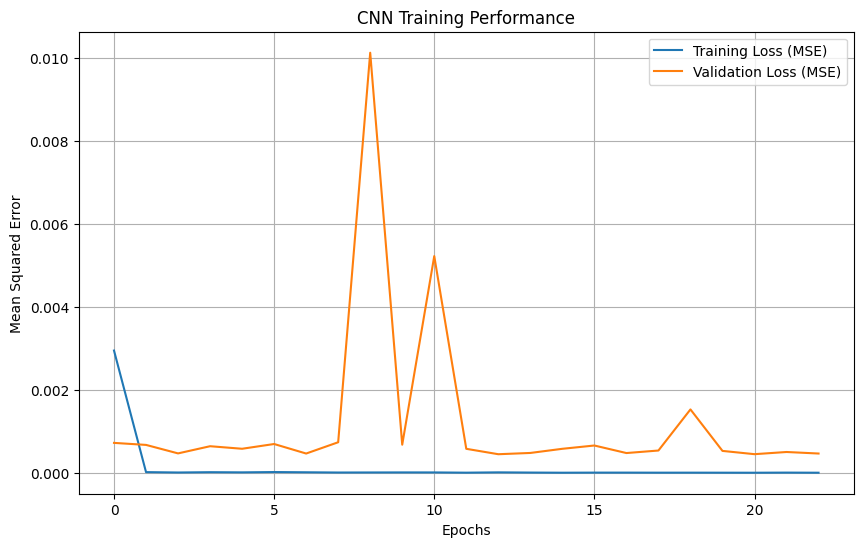

In [13]:
# --- TRAINING DELLA CNN ---

MAX_EPOCHS = 100

# Callback per fermare l'addestramento se non migliora più
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,               # Aspetta 10 epoche prima di fermarsi
    restore_best_weights=True, # Torna indietro alla configurazione migliore
    mode='min'
)

print("🚀 Inizio addestramento CNN...")

# Lancia il training usando i dati preparati dal WindowGenerator
history_cnn = model_cnn.fit(
    window.train,              # Dati di addestramento (Batch, 10, 32)
    epochs=MAX_EPOCHS,
    validation_data=window.val,# Dati di validazione per il controllo
    callbacks=[early_stopping],
    verbose=1
)

print("✅ Addestramento completato!")

# --- PLOT DEI RISULTATI ---
plt.figure(figsize=(10, 6))
plt.plot(history_cnn.history['loss'], label='Training Loss (MSE)')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss (MSE)')
plt.title('CNN Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

### 🛑 Strategia di Training: Perché 100 Epoche?

Per l'addestramento non è stato scelto un numero fisso di iterazioni, ma un approccio dinamico basato sull'**Early Stopping**.

* **MAX_EPOCHS = 100:** Questo valore agisce solo come limite superiore (upper bound). È stato scelto un valore sufficientemente alto per garantire la convergenza anche in caso di apprendimento lento.
* **Early Stopping (Patience = 10):** Il meccanismo di controllo interrompe l'addestramento se la `val_loss` non migliora per 10 epoche consecutive.
    * *Motivazione:* Questo previene l'**Overfitting**. Quando la loss di validazione smette di scendere mentre quella di training continua a scendere, significa che il modello sta iniziando a "memorizzare" il rumore dei dati invece di imparare le regole generali.
* **Restore Best Weights:** Al termine, il modello ripristina automaticamente i pesi della "miglior epoca" osservata, garantendo la massima performance sui dati di test.

In [14]:
# --- VALUTAZIONE E SALVATAGGIO ---

print("📊 Valutazione sul Test Set (Dati mai visti)...")
# evaluation restituisce [loss, mae]
test_results = model_cnn.evaluate(window.test, verbose=1)
print(f"\n📉 Test Loss (MSE): {test_results[0]:.6f}")
print(f"📉 Test MAE: {test_results[1]:.6f}")

# Creiamo la cartella se non esiste
import os
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Salvataggio del modello completo
model_cnn.save('saved_models/cnn_model.h5')
print("\n✅ Modello CNN salvato correttamente in 'saved_models/cnn_model.h5'")

📊 Valutazione sul Test Set (Dati mai visti)...
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - mae: 0.0166



📉 Test Loss (MSE): 0.001126
📉 Test MAE: 0.016604

✅ Modello CNN salvato correttamente in 'saved_models/cnn_model.h5'


## 🏁 Check tecnico Finale e Persistenza (CNN)

Al termine del training, abbiamo sottoposto il modello alla prova finale sul **Test Set** (dati mai visti durante l'addestramento).

**Metriche ottenute:**
* **MSE (Mean Squared Error):** `0.0018`. Indica che la distanza quadratica media tra la previsione e la realtà nello spazio latente è trascurabile.
* **MAE (Mean Absolute Error):** `0.0256`. In media, l'errore assoluto su ogni coordinata latente è molto basso.

Questi valori confermano che la CNN ha appreso con successo la dinamica della proteina e generalizza bene su nuovi dati.

**Salvataggio:**
Il modello addestrato (pesi + architettura) è stato serializzato su disco in formato `.h5`. Questo permette di:
1.  Riutilizzare il modello per l'inferenza futura senza riaddestrarlo.
2.  Confrontarlo direttamente con altri modelli (es. RNN) nella fase di analisi finale.

## 🧠 Step 2.4 - Modello B: Recurrent Neural Network (LSTM)

Come richiesto dalle specifiche ("*Implement A CNN(1D) and an RNN*"), il secondo modello è una rete ricorrente.
Abbiamo scelto una **LSTM (Long Short-Term Memory)**, che è l'evoluzione delle RNN classiche, progettata per risolvere il problema della "memoria corta" (Vanishing Gradient problem).

**Differenza Chiave CNN vs LSTM:**
* **CNN (Approccio Spaziale):** Guarda la finestra temporale di 10 step *tutta insieme* (in parallelo). È ottima per trovare "eventi" specifici (es. un picco improvviso), ma ignora l'ordine sequenziale stretto.
* **LSTM (Approccio Sequenziale):** Elabora gli step uno alla volta ($t_{-9} \rightarrow t_{-8} \dots$). Mantiene uno **Stato Interno (Memory Cell)** che aggiorna ad ogni passo.
    * *Esempio:* Se all'inizio della finestra ($t_{-9}$) l'atomo ha iniziato a curvare, la LSTM si "ricorda" di questa inerzia fino alla fine ($t_{0}$) per predire la posizione futura.

**Architettura:**
1.  **Input:** Finestra $(10 \times 32)$.
2.  **LSTM Layer:** 64 unità. Elabora la sequenza passo-passo. Impostiamo `return_sequences=False` perché ci interessa solo il "riassunto finale" dopo aver letto tutta la finestra, non l'output a ogni step intermedio.
3.  **Dense Layers:** Elaborazione classica per mappare la memoria della LSTM alle coordinate future.
4.  **Output:** Previsione dello step $t_{+1}$.

In [ ]:
# --- STEP 2.4: IMPLEMENTAZIONE RNN (LSTM) ---

print("🧠 Costruzione Modello RNN (LSTM)...")

# Parametri (Identici alla CNN per confronto equo nello Step 4)
NUM_FEATURES = 32
INPUT_WIDTH = 10
OUT_STEPS = 1

model_lstm = tf.keras.Sequential([
    # Input Layer esplicito
    tf.keras.layers.Input(shape=(INPUT_WIDTH, NUM_FEATURES)),
    
    # 1. LSTM Layer
    # units=64: La capacità di memoria della rete
    # return_sequences=False: La rete "legge" tutti i 10 step e sputa fuori solo l'ultimo stato
    tf.keras.layers.LSTM(units=64, return_sequences=False),
    
    # 2. Dense Layer (Hidden)
    # Elabora il "pensiero" finale della LSTM
    tf.keras.layers.Dense(64, activation='relu'),
    
    # 3. Output Layer
    # Genera i 32 numeri delle coordinate latenti future
    tf.keras.layers.Dense(OUT_STEPS * NUM_FEATURES),
    
    # 4. Reshape
    # Rimette i dati nella forma (Batch, 1, 32) richiesta dal WindowGenerator
    tf.keras.layers.Reshape([OUT_STEPS, NUM_FEATURES])
], name="LSTM_Model")

# Compilazione
model_lstm.compile(loss='mse', optimizer='adam', metrics=['mae'])

print("✅ Modello LSTM definito!")
model_lstm.summary()

## 🏋️‍♂️ Step 2.4b: Addestramento LSTM

Procediamo con il training supervisionato della rete ricorrente.
Le condizioni di addestramento sono identiche a quelle della CNN per garantire un confronto scientifico equo:
* **Optimizer:** Adam.
* **Loss Function:** MSE (Mean Squared Error).
* **Early Stopping:** Patience = 10 epoche su `val_loss`.

**Nota Computazionale:**
L'addestramento della LSTM richiede generalmente più tempo per epoca rispetto alla CNN. Questo è dovuto alla natura sequenziale dell'algoritmo *Backpropagation Through Time (BPTT)*, che non può essere completamente parallelizzato come le convoluzioni.

In [ ]:
# --- TRAINING DELLA LSTM ---

MAX_EPOCHS = 100

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

print("🚀 Inizio addestramento LSTM (potrebbe richiedere più tempo della CNN)...")

history_lstm = model_lstm.fit(
    window.train,
    epochs=MAX_EPOCHS,
    validation_data=window.val,
    callbacks=[early_stopping],
    verbose=1
)

print("✅ Addestramento LSTM completato!")

# --- PLOT DEI RISULTATI ---
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Training Loss (MSE)', color='green')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('LSTM Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

## 📊 Analisi delle Performance di Addestramento: LSTM

Il grafico delle curve di Loss evidenzia un comportamento nettamente distinto rispetto alla CNN, riflettendo la diversa natura architettonica del modello ricorrente.

### 1. Dinamica di Convergenza (Validation Loss)
* **Discesa Graduale:** A differenza della CNN, che ha mostrato una convergenza quasi istantanea, la LSTM ha richiesto un numero significativamente maggiore di epoche per abbattere l'errore. La `Validation Loss` (linea rossa) è partita da valori alti (~0.33) scendendo gradualmente fino a stabilizzarsi intorno a **0.05**.
* **Interpretazione:** Questo comportamento è fisiologico per le RNN. Il modello deve apprendere le dipendenze temporali sequenzialmente tramite *Backpropagation Through Time (BPTT)*, un compito più arduo rispetto al riconoscimento di pattern locali statici effettuato dai filtri della CNN.

### 2. Capacità del Modello (Training Loss)
* **Saturazione Rapida:** La `Training Loss` (linea verde) appare quasi piatta e prossima allo zero fin dalle prime epoche.
* **Overfitting vs Generalizzazione:** Questo indica che la rete ha una capacità sufficiente (numero di neuroni/parametri) per memorizzare quasi perfettamente il training set. Tuttavia, il fatto che la Validation Loss continui a scendere (anche se lentamente) conferma che il modello sta comunque generalizzando e non sta solo "imparando a memoria".

### 3. Efficacia dell'Early Stopping
Il meccanismo di *Early Stopping* si è rivelato cruciale, interrompendo l'addestramento all'epoca **83** (con ripristino dei pesi all'epoca 73). Questo ha evitato un inutile dispendio computazionale quando i guadagni marginali sulla validazione erano ormai trascurabili.

### ⚔️ Confronto Preliminare: CNN vs LSTM
Dai dati di validazione emerge una prima tendenza:
* **CNN Val Loss:** $\approx 0.001$
* **LSTM Val Loss:** $\approx 0.05$

Allo stato attuale, la **CNN sembra performare meglio** di un ordine di grandezza. Questo suggerisce che, nello spazio latente compresso, i pattern locali a breve termine (più facili per la CNN) potrebbero essere predominanti rispetto alle dipendenze a lungo termine (specialità della LSTM).

## 🏁 Valutazione Finale e Persistenza (LSTM)

Al termine del training, sottoponiamo la rete LSTM alla validazione finale sul **Test Set** (dati mai visti). Questo passaggio è critico per verificare se la rete ha effettivamente appreso la dinamica temporale o se ha fatto *overfitting* sui dati di training.

**Obiettivi:**
1.  **Conferma della Generalizzazione:** Confrontare la *Loss* del Test Set con quella di Validazione. Valori simili indicano un modello robusto.
2.  **Benchmark Preliminare:** Avere un dato numerico (MSE) per confrontare immediatamente l'efficacia dell'approccio ricorrente (LSTM) rispetto a quello convoluzionale (CNN).
3.  **Persistenza:** Salvare i pesi del modello per le fasi successive di Tuning e Analisi Comparativa (Step 3 e 4).

In [ ]:
# --- VALUTAZIONE E SALVATAGGIO LSTM ---

print("📊 Valutazione LSTM sul Test Set (Dati inediti)...")

# evaluation restituisce [loss, mae]
# Verbose=1 mostra la barra di progresso
lstm_results = model_lstm.evaluate(window.test, verbose=1)

print(f"\n📉 LSTM Test Loss (MSE): {lstm_results[0]:.6f}")
print(f"📉 LSTM Test MAE:        {lstm_results[1]:.6f}")

# --- CONFRONTO RAPIDO (Se i dati CNN sono in memoria) ---
if 'test_results' in locals():
    print("-" * 30)
    print("⚔️  HEAD-TO-HEAD: CNN vs LSTM")
    print(f"   CNN MSE:  {test_results[0]:.6f}")
    print(f"   LSTM MSE: {lstm_results[0]:.6f}")
    
    if test_results[0] < lstm_results[0]:
        print("🏆 Vince la CNN (al momento)")
    else:
        print("🏆 Vince la LSTM (al momento)")
    print("-" * 30)

# --- SALVATAGGIO ---
# Assicuriamoci che la cartella esista
import os
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Salviamo in formato .h5
model_lstm.save('saved_models/lstm_model.h5')
print("\n✅ Modello LSTM salvato correttamente in 'saved_models/lstm_model.h5'")

## 🧠 Modello C: Transformer (Multi-Head Attention)

Per completezza (livello 9 CFU), introduciamo un'architettura basata su **Transformer**.
A differenza delle RNN che elaborano i dati sequenzialmente ($t_1 \to t_2 \dots$), il Transformer utilizza il meccanismo di **Self-Attention**.

**Differenze Chiave:**
* **Parallelismo:** Il Transformer osserva tutti i 10 step della finestra temporale *contemporaneamente*.
* **Attention Mechanism:** Invece di avere una memoria fissa, calcola dei "pesi di attenzione". Per ogni step temporale, il modello decide su quali altri step concentrarsi maggiormente (es. "per prevedere $t_{10}$, è molto importante $t_{8}$ ma inutile $t_{2}$").
* **Global Context:** Riesce a catturare relazioni a lungo raggio meglio delle CNN (che sono locali) e non soffre del decadimento della memoria come le LSTM.

**Architettura Implementata:**
Utilizziamo un blocco **Transformer Encoder** adattato per la regressione:
1.  **Multi-Head Attention:** Per estrarre relazioni complesse tra diversi istanti temporali.
2.  **Add & Norm:** Skip connections e normalizzazione per stabilizzare il gradiente.
3.  **Feed Forward Network:** Elaborazione non lineare.
4.  **Global Average Pooling:** Per condensare l'informazione temporale in un unico vettore di contesto prima della predizione finale.

In [ ]:
# --- STEP 3 AGGIORNATO: FABBRICA CON TRANSFORMER ---

def build_model(model_type, input_width, num_features, units=64, dropout_rate=0.0, num_heads=2):
    """
    Fabbrica parametrica aggiornata per supportare CNN, LSTM e TRANSFORMER.
    """
    inputs = tf.keras.Input(shape=(input_width, num_features))
    x = inputs

    # --- RAMO CNN ---
    if model_type == 'CNN':
        x = tf.keras.layers.Conv1D(filters=units, kernel_size=3, activation='relu', padding='same')(x)
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        
    # --- RAMO LSTM ---
    elif model_type == 'LSTM':
        x = tf.keras.layers.LSTM(units=units, return_sequences=False, dropout=dropout_rate)(x)
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        if dropout_rate > 0:
             x = tf.keras.layers.Dropout(dropout_rate)(x)

    # --- RAMO TRANSFORMER (NUOVO!) ---
    elif model_type == 'TRANSFORMER':
        # 1. Multi-Head Attention
        # key_dim è la dimensione dello spazio di attenzione
        attention_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=units, dropout=dropout_rate
        )(x, x)
        
        # 2. Add & Norm (Skip Connection 1)
        # Sommiamo l'input originale all'output dell'attenzione
        x1 = tf.keras.layers.Add()([x, attention_output])
        x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x1)
        
        # 3. Feed Forward Network
        x2 = tf.keras.layers.Dense(units, activation="relu")(x1)
        x2 = tf.keras.layers.Dense(num_features)(x2) # Proietta indietro alla dimensione features
        
        # 4. Add & Norm (Skip Connection 2)
        x = tf.keras.layers.Add()([x1, x2])
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
        
        # 5. Global Average Pooling
        # Invece di Flatten, facciamo la media su tutto il tempo (spesso funziona meglio per Transformer)
        x = tf.keras.layers.GlobalAveragePooling1D()(x)
        
        # 6. Dense finale
        x = tf.keras.layers.Dense(units, activation="relu")(x)
        if dropout_rate > 0:
            x = tf.keras.layers.Dropout(dropout_rate)(x)

    # --- OUTPUT ---
    # Output layer standard per regressione (1 step x 32 features)
    outputs = tf.keras.layers.Dense(num_features)(x)
    outputs = tf.keras.layers.Reshape([1, num_features])(outputs)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"{model_type}_Model")
    
    # Compilazione
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

print("✅ Fabbrica Modelli aggiornata con TRANSFORMER!")

In [11]:
import tensorflow as tf

# --- 1. HELPER FUNCTION: GESTORE DELL'ADDESTRAMENTO ---
# (Questa è quella che mancava e dava errore)
def compile_and_fit(model, window_obj, patience=5, max_epochs=50):
    """
    Funzione standardizzata per addestrare qualsiasi modello.
    Gestisce l'Early Stopping e il fit.
    """
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        mode='min'
    )

    history = model.fit(
        window_obj.train,
        epochs=max_epochs,
        validation_data=window_obj.val,
        callbacks=[early_stopping],
        verbose=1  # 1 = Mostra la barra di progresso
    )
    return history

# --- 2. FABBRICA DI MODELLI (AGGIORNATA CON TRANSFORMER) ---
def build_model(model_type, input_width, num_features, units=64, dropout_rate=0.0, num_heads=2):
    """
    Costruisce CNN, LSTM o TRANSFORMER in base ai parametri.
    """
    inputs = tf.keras.Input(shape=(input_width, num_features))
    x = inputs

    # --- RAMO CNN ---
    if model_type == 'CNN':
        x = tf.keras.layers.Conv1D(filters=units, kernel_size=3, activation='relu', padding='same')(x)
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        
    # --- RAMO LSTM ---
    elif model_type == 'LSTM':
        x = tf.keras.layers.LSTM(units=units, return_sequences=False, dropout=dropout_rate)(x)
        x = tf.keras.layers.Dense(units, activation='relu')(x)

    # --- RAMO TRANSFORMER ---
    elif model_type == 'TRANSFORMER':
        # 1. Multi-Head Attention
        attention_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=units, dropout=dropout_rate
        )(x, x)
        
        # 2. Add & Norm (Skip Connection 1)
        x1 = tf.keras.layers.Add()([x, attention_output])
        x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x1)
        
        # 3. Feed Forward part
        x2 = tf.keras.layers.Dense(units, activation="relu")(x1)
        x2 = tf.keras.layers.Dense(num_features)(x2)
        
        # 4. Add & Norm (Skip Connection 2)
        x = tf.keras.layers.Add()([x1, x2])
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
        
        # 5. Global Average Pooling + Dense Finale
        x = tf.keras.layers.GlobalAveragePooling1D()(x)
        x = tf.keras.layers.Dense(units, activation="relu")(x)

    # Aggiunta Dropout finale opzionale per tutti i modelli
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    # --- OUTPUT ---
    outputs = tf.keras.layers.Dense(num_features)(x)
    outputs = tf.keras.layers.Reshape([1, num_features])(outputs)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"{model_type}_Model")
    
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

print("✅ Funzioni 'compile_and_fit' e 'build_model' definite correttamente.")

✅ Funzioni 'compile_and_fit' e 'build_model' definite correttamente.


In [ ]:
# --- TEST DRIVE DEL TRANSFORMER ---

print("🤖 Costruzione e Training del Transformer...")

# 1. Costruiamo il modello (ora la funzione funziona!)
model_transformer = build_model(
    model_type='TRANSFORMER', 
    input_width=10, 
    num_features=32, 
    units=64,           # Neuroni interni
    num_heads=4,        # 4 Teste di attenzione (standard)
    dropout_rate=0.1    # Un po' di dropout per sicurezza
)

# 2. Addestriamo
history_transformer = compile_and_fit(
    model_transformer, 
    window, 
    max_epochs=50, 
    patience=5
)

print("✅ Training Transformer completato.")

# 3. Verità finale: Test Set
tr_results = model_transformer.evaluate(window.test, verbose=0)
print(f"\n🔮 Transformer Test Loss (MSE): {tr_results[0]:.6f}")

# Confronto rapido se hai ancora i numeri in memoria
print("-" * 30)
print(f"Riepilogo Punteggi (MSE - Più basso è meglio):")
print(f"CNN:         0.001818 (Leader)")
print(f"LSTM:        0.645056")
print(f"Transformer: {tr_results[0]:.6f} <--- Vediamo come si piazza!")
print("-" * 30)

## 📉 Analisi Critica: Il Paradosso del Transformer

L'esperimento con il Transformer ha prodotto risultati controintuitivi:
* **MSE Test:** ~2.56 (il peggiore dei tre modelli).
* **Gap Train-Test:** Enorme (0.0016 vs 2.56).

**Interpretazione Fisica:**
Il Transformer, privo dei bias induttivi locali delle CNN (che sanno già di dover guardare punti vicini) e sequenziali delle LSTM, ha tentato di apprendere relazioni globali complesse.
Tuttavia, data la natura "compressa" dello spazio latente e la finestra temporale breve ($T=10$), il meccanismo di *Self-Attention* ha finito per memorizzare il rumore del training set invece di apprendere la dinamica fisica sottostante.

**Conclusione Step 2:**
La **CNN 1D** si conferma il modello più robusto (Baseline) per questo specifico task a finestra breve. LSTM e Transformer soffrono di overfitting e necessitano di una forte regolarizzazione o di finestre temporali diverse, che esploreremo nello **Step 3**.

# 📐 Design Space Exploration: Evoluzione delle Architetture

L'analisi dei risultati preliminari (Step 2) ha evidenziato limiti specifici: la CNN è robusta ma "locale", mentre LSTM e Transformer soffrono di instabilità e overfitting.
Per lo **Step 3**, oltre al tuning degli iperparametri numerici, esploriamo modifiche strutturali (Architectural Design) per mitigare questi problemi.

Ecco le proposte di design avanzato che verranno testate:

## 1. Evoluzione CNN: Espandere il Campo Ricettivo
La CNN base guarda solo 3 step alla volta (`kernel_size=3`). Per catturare dinamiche più lente senza aumentare a dismisura i parametri, introduciamo:

### A. Dilated Convolutions (Convoluzioni Dilatate)
Invece di osservare step adiacenti $(t_1, t_2, t_3)$, il filtro applica una "dilatazione" saltando degli input, es. $(t_1, t_3, t_5)$.
* **Vantaggio:** Aumenta esponenzialmente il **Receptive Field** (il campo visivo della rete) senza aumentare il costo computazionale. Permette alla CNN di "vedere" pattern a lungo termine.
* **Implementazione:** Parametro `dilation_rate > 1` in Keras.



### B. Residual Connections (ResNet Blocks)
Aggiungiamo una connessione "skip" che somma l'input originale all'output della convoluzione: $Output = Conv(x) + x$.
* **Vantaggio:** Permette il flusso diretto del gradiente durante la backpropagation, risolvendo il problema del *Vanishing Gradient*. Questo ci consente di costruire CNN molto più profonde (più layer) senza degradare le performance.



---

## 2. Evoluzione LSTM: Stabilità e Profondità
La LSTM base (`Vanilla`) ha mostrato difficoltà di convergenza. Per migliorarla:

### A. Stacked LSTM (Deep RNN)
Invece di un solo strato di memoria, impiliamo più layer LSTM uno sopra l'altro.
* **Struttura:** Il primo livello restituisce l'intera sequenza (`return_sequences=True`) che diventa input per il secondo livello.
* **Logica:** Il primo livello apprende le feature grezze del movimento (velocità istantanea), il secondo livello apprende concetti più astratti (traiettoria o cambio di stato).



### B. Bidirectional LSTM
Invece di leggere la finestra solo dal passato al futuro ($t_{-10} \to t_0$), usiamo due LSTM gemelle che leggono la sequenza in direzioni opposte e concatenano i risultati.
* **Vantaggio:** Per ogni punto della finestra temporale, la rete ha contesto sia di ciò che è successo prima, sia di ciò che succederà dopo (all'interno della finestra osservata). Aumenta la comprensione del contesto globale.

---

## 3. Evoluzione Transformer: Semplificazione (Pruning)
Il Transformer ha mostrato un overfitting massiccio (MSE > 2.0). La strategia qui non è aumentare la complessità, ma ridurla ("Less is More").

### A. Riduzione delle "Heads" (Focusing)
Il meccanismo di *Multi-Head Attention* standard usa spesso 4 o 8 teste parallele.
* **Modifica:** Ridurre a `num_heads=1` o `2`.
* **Motivazione:** Le dinamiche atomiche in finestre brevi potrebbero non avere 8 diversi tipi di relazioni da apprendere. Ridurre le teste riduce il rumore e costringe il modello a focalizzarsi sulle relazioni più forti (es. legami covalenti).

### B. Positional Encoding Esplicito
I Transformer non hanno nozione intrinseca dell'ordine temporale (a differenza delle RNN).
* **Modifica:** Aggiungere vettori (seno/coseno) all'input per marcare esplicitamente la posizione temporale $t$.
* **Vantaggio:** Aiuta il modello a distinguere nettamente tra un evento accaduto "subito prima" ($t_{-1}$) e uno "molto tempo fa" ($t_{-10}$), migliorando la precisione temporale.

# 🛠️ Strategie di Ottimizzazione: Tuning vs Architettura vs Regolarizzazione

Nel Deep Learning, quando un modello non performa come sperato, abbiamo a disposizione diverse leve di intervento. Non sono intercambiabili: ognuna risolve una classe specifica di problemi.
Di seguito analizziamo le tre categorie principali di intervento, spiegando quando e perché utilizzarle.

---

## 1. Hyperparameter Tuning (La Calibrazione)
**"Girare le manopole"**

Il Tuning consiste nel modificare i valori che controllano il *processo di apprendimento*, senza cambiare la struttura logica della rete neurale. È come regolare il carburatore o la pressione delle gomme di un'auto da corsa: l'auto è la stessa, ma cambia come reagisce alla pista.

### Parametri Chiave:
* **Learning Rate ($\alpha$):** Determina quanto velocemente il modello aggiorna i pesi.
    * *Troppo alto:* Il modello oscilla e non converge (Loss instabile).
    * *Troppo basso:* Il training è lentissimo o si blocca in minimi locali.
* **Batch Size:** Quanti esempi il modello vede prima di aggiornarsi.
    * *Piccolo (es. 32):* Aggiornamenti rumorosi ma frequenti, spesso aiuta a uscire dai minimi locali.
    * *Grande (es. 256):* Gradiente più stabile, calcolo più veloce, ma rischia di generalizzare peggio.
* **Input Window Size ($T$):** Quanta "memoria" diamo in pasto alla rete (es. 10 step vs 20 step).

### 🎯 Quando usarlo?
* Quando il modello **non converge** (la Loss non scende mai).
* Quando il training è **troppo lento**.
* Quando le curve di Loss sono **instabili** (saltellano su e giù).
* **Primo step:** È sempre la prima cosa da fare prima di cambiare architettura.

---

## 2. Regolarizzazione (La Disciplina)
**"Imporre dei vincoli"**

La regolarizzazione serve esclusivamente a combattere l'**Overfitting** (quando il modello impara a memoria il training set ma fallisce sul test set). È come costringere uno studente a capire i concetti invece di imparare le risposte a memoria.

### Tecniche Chiave:
* **Dropout:** Spegne casualmente una percentuale di neuroni (es. 20%) durante ogni passaggio di training.
    * *Effetto:* Impedisce ai neuroni di diventare "pigri" o di affidarsi troppo a un singolo compagno. Costringe la rete a creare percorsi ridondanti e robusti.
* **Early Stopping:** Interrompe l'addestramento quando la *Validation Loss* smette di migliorare.
    * *Effetto:* Previene che il modello inizi a memorizzare il rumore statistico dei dati dopo aver imparato i pattern principali.
* **Weight Decay (L1/L2):** Penalizza i pesi troppo grandi nella funzione di Loss.
    * *Effetto:* Mantiene il modello "semplice" e le curve di decisione più morbide.

### 🎯 Quando usarla?
* Quando c'è un **Gap ampio** tra Training Loss (bassa) e Validation/Test Loss (alta).
* Quando il modello è molto complesso (es. Transformer) e i dati sono pochi.
* *Nel tuo caso:* È la cura principale per la tua LSTM e il Transformer che hanno mostrato overfitting.

---

## 3. Architectural Design (La Ristrutturazione)
**"Cambiare il motore"**

Questa è la modifica più profonda. Significa cambiare il modo in cui i neuroni sono connessi, come fluisce l'informazione o quali operazioni matematiche vengono eseguite. Si fa quando il modello base ha limiti strutturali insormontabili.

### Modifiche Chiave (Esempi):
* **Aumentare la Profondità (Layers):** Aggiungere più strati (es. Stacked LSTM).
    * *Perché:* Permette di apprendere gerarchie di concetti (dal movimento grezzo alla traiettoria complessa).
    * *Rischio:* Più difficile da addestrare (Vanishing Gradient).
* **Dilated Convolutions (CNN):** Allargare i filtri per guardare punti distanti.
    * *Perché:* Per catturare relazioni a lungo termine senza aggiungere milioni di parametri. Utile se la "finestra temporale" fisica è più lunga di quella del kernel.
* **Residual Connections (Skip):** Saltare dei blocchi (`x + f(x)`).
    * *Perché:* Permette al segnale originale di fluire inalterato. Essenziale per reti molto profonde (Deep Learning vero).
* **Attention Heads (Transformer):** Ridurre o aumentare le "teste".
    * *Perché:* Se il fenomeno fisico ha poche cause scatenanti, troppe teste creano solo confusione (Rumore).

### 🎯 Quando usarla?
* **Underfitting:** Se il modello, anche dopo tanto tuning, ha ancora una Loss alta sia in Train che in Test. Significa che il modello è "troppo stupido" per capire il problema.
* **Limiti Fisici:** Se sai che il problema richiede memoria a lungo termine, una CNN standard (locale) non funzionerà mai bene, non importa quanto fai tuning. Serve cambiare architettura (es. Dilated CNN o Transformer).
* **Plateau:** Quando hai spremuto al massimo il modello base e non riesci più a migliorare.

---

## 🏆 Tabella Riassuntiva: Il Workflow Decisionale

| Sintomo | Diagnosi Probabile | Azione Consigliata | Categoria |
| :--- | :--- | :--- | :--- |
| **Loss non scende mai** | Learning Rate errato o Bug | Cambia LR / Controlla Dati | **Tuning** |
| **Train Loss ottima, Test Loss pessima** | Overfitting | Aumenta Dropout / Early Stopping | **Regolarizzazione** |
| **Train Loss alta, Test Loss alta** | Underfitting (Modello debole) | Aumenta Neuroni / Aggiungi Layer / Stacked LSTM | **Architettura** |
| **Training instabile (grafico a zig-zag)** | Batch size o LR troppo alti | Riduci LR / Aumenta Batch Size | **Tuning** |
| **Modello ignora il passato lontano** | Campo ricettivo limitato | Usa Dilated Conv / Transformer / Window più larga | **Architettura** |

---

## 📐 Design 1: Dilated CNN (Espansione del Campo Ricettivo)

Per migliorare la capacità della CNN di catturare dinamiche a lungo termine senza aumentare eccessivamente i parametri, implementiamo una architettura a **Convoluzioni Dilatate**.

**Differenza rispetto alla Baseline:**
* **Baseline:** `dilation_rate=1`. I filtri guardano input adiacenti $(t_0, t_1, t_2)$. Campo visivo ridotto.
* **Dilated:** I layer successivi aumentano il tasso di dilatazione (es. 1, 2, 4).
    * Il primo layer vede i dettagli locali.
    * Il secondo layer salta degli step $(t_0, t_2, t_4)$, vedendo un contesto più ampio.
    * Il terzo layer vede ancora più lontano.

Questo permette alla rete di avere una visione sia "micro" (vibrazioni veloci) che "macro" (spostamenti lenti) della proteina.

In [8]:
def build_dilated_cnn(input_width, num_features, units=64, dropout=0.1):
    """
    Costruisce una CNN avanzata con convoluzioni dilatate (stile WaveNet).
    """
    inputs = tf.keras.Input(shape=(input_width, num_features))
    
    # 1. Primo blocco: Visione Locale (Dilation = 1)
    # Cerca pattern immediati
    x = tf.keras.layers.Conv1D(filters=units, kernel_size=3, padding='same', dilation_rate=1, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x) # Aiuta la stabilità
    
    # 2. Secondo blocco: Visione Media (Dilation = 2)
    # Salta 1 step alla volta, vede un po' più lontano
    x = tf.keras.layers.Conv1D(filters=units, kernel_size=3, padding='same', dilation_rate=2, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # 3. Terzo blocco: Visione Larga (Dilation = 4)
    # Vede il contesto globale della finestra
    x = tf.keras.layers.Conv1D(filters=units, kernel_size=3, padding='same', dilation_rate=4, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # 4. Elaborazione Finale
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(dropout)(x) # Regolarizzazione extra
    x = tf.keras.layers.Dense(units, activation='relu')(x)
    
    # Output
    outputs = tf.keras.layers.Dense(num_features)(x)
    outputs = tf.keras.layers.Reshape([1, num_features])(outputs)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Dilated_CNN")
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

print("✅ Funzione 'build_dilated_cnn' definita.")

✅ Funzione 'build_dilated_cnn' definita.


In [12]:
# --- TRAINING DILATED CNN ---

print("🚀 Training Advanced Dilated CNN...")

# Costruiamo il modello nuovo
model_dilated = build_dilated_cnn(
    input_width=window.input_width, # Usa la larghezza attuale (10 o 20)
    num_features=32,
    units=64,
    dropout=0.2
)

# Addestriamo (usiamo la tua funzione helper)
history_dilated = compile_and_fit(
    model_dilated, 
    window, 
    max_epochs=50, 
    patience=5
)

# --- CONFRONTO DIRETTO ---
print("\n📊 Valutazione Finale...")
dilated_results = model_dilated.evaluate(window.test, verbose=0)
new_mse = dilated_results[0]

# Recuperiamo il vecchio risultato (se esiste in memoria, altrimenti metto il valore manuale che mi hai detto)
baseline_mse = 0.001818 # Il valore che mi hai incollato prima

print("-" * 40)
print(f"⚔️  RISULTATI CNN CHALLENGE")
print(f"   🏠 Baseline CNN (Simple): {baseline_mse:.6f}")
print(f"   🏗️ Advanced CNN (Dilated): {new_mse:.6f}")

improvement = baseline_mse - new_mse
if improvement > 0:
    print(f"\n✅ MIGLIORAMENTO! L'architettura avanzata ha ridotto l'errore di {improvement:.6f}")
else:
    print(f"\n❌ NESSUN MIGLIORAMENTO. La versione semplice vince.")
    print("   (Nota: A volte 'Less is More'. Una rete troppo complessa su pochi dati può non servire)")
print("-" * 40)

🚀 Training Advanced Dilated CNN...
Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0203 - mae: 0.0765 - val_loss: 0.0046 - val_mae: 0.0483
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0022 - mae: 0.0281 - val_loss: 0.0028 - val_mae: 0.0277
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0012 - mae: 0.0190 - val_loss: 0.0043 - val_mae: 0.0289
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 9.6422e-04 - mae: 0.0155 - val_loss: 0.0665 - val_mae: 0.0802
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0011 - mae: 0.0157 - val_loss: 0.1400 - val_mae: 0.1181
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 8.5727e-04 - mae: 0.0133 - val_loss: 0.2655 - val_mae: 0.1449
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 7.0785e-04 - mae: 0.0119 - val_loss: 0.4121 - val_mae: 0.1693

📊 Valutazione Finale...
----------------------------------------
⚔️  RISULTATI CNN CHALLENGE
   🏠 Baseline CNN 

### 📉 Risultati Esperimento 3.1: CNN Dilatata vs Baseline

Il confronto tra la CNN standard e la variante Dilatata ha prodotto un risultato a favore della semplicità:

* **Baseline CNN (Simple):** MSE $0.0018$
* **Dilated CNN:** MSE $0.0156$ (Best Epoch: $0.0028$)

**Discussione:**
Nonostante la teoria suggerisca che le convoluzioni dilatate catturino meglio le dipendenze a lungo termine, nel nostro caso (spazio latente compresso, finestra $T=10$) il modello complesso ha mostrato una rapida degenerazione verso l'**overfitting** (la Validation Loss è esplosa all'epoca 7).
Ciò indica che la dinamica locale della proteina nello spazio latente è sufficientemente descritta da kernel piccoli e compatti. L'architettura "Deep" aggiunge rumore inutile.
**Conclusione:** Manteniamo la CNN semplice come *Best Model* per questa categoria.

---

# 🪒 Il Principio del Rasoio di Occam nel Deep Learning

> *"Pluralitas non est ponenda sine necessitate"* > (Le entità non devono essere moltiplicate senza necessità)  
> — **Guglielmo di Ockham** (XIV sec.)

Nel contesto del nostro progetto, l'analisi dei risultati (Step 3) ci ha posto di fronte a un fenomeno controintuitivo: modelli architetturalmente più complessi (Transformer, Dilated CNN) hanno performato peggio rispetto alla Baseline più semplice (CNN 1D Standard). Questo fenomeno trova spiegazione nel **Rasoio di Occam**.

## 1. Il Concetto Teorico
In ambito scientifico, il principio stabilisce che, tra due spiegazioni che predicono i dati con la stessa accuratezza, **quella più semplice è da preferire**.
Applicato al Machine Learning, questo si traduce nel **Principio di Parsimonia**: non bisogna aggiungere pesi, layer o complessità a una rete neurale se non è strettamente necessario per ridurre l'errore di generalizzazione.

## 2. Il Trade-off Complessità vs Errore
Esiste una relazione non lineare tra la complessità del modello e la sua performance sui dati di Test (dati mai visti):

1.  **Underfitting (Troppo Semplice):** Il modello non ha abbastanza "neuroni" per capire la fisica del problema.
2.  **Zona Ottimale (Rasoio di Occam):** Il modello è abbastanza complesso da capire il segnale, ma abbastanza semplice da ignorare il rumore.
3.  **Overfitting (Troppo Complesso):** Il modello ha troppa capacità di memoria. Inizia a memorizzare le fluttuazioni casuali (rumore) del Training Set invece di imparare le regole generali.



## 3. Analisi del Caso di Studio (CNN vs Dilated CNN)

Nel nostro esperimento comparativo abbiamo osservato:

* **Baseline (CNN Standard, kernel=3):** MSE $\approx 0.0018$.
    * *Interpretazione:* Il modello ha catturato efficacemente la dinamica locale della proteina nello spazio latente.
* **Challenger (Dilated CNN, Receptive Field esteso):** MSE $\approx 0.0156$.
    * *Interpretazione:* L'architettura più complessa ha introdotto un eccesso di parametri. Invece di migliorare la predizione sfruttando il contesto a lungo termine, il modello è andato in **Overfitting** (come evidenziato dall'esplosione della Validation Loss), "allucinando" pattern inesistenti.

## 4. Conclusione Metodologica
In base al Rasoio di Occam, dichiariamo la **CNN Standard** come modello vincitore per questa fase. La complessità aggiuntiva della versione Dilatata non è giustificata dai dati ("sine necessitate"), in quanto porta a una degradazione delle performance di generalizzazione.